# Reading the data


In [1]:
import pandas as pd
df = pd.read_excel(r'C:\Users\Mirnalini\Relap.xlsx',na_values=['BLANK'])
df_c = df.copy()

In [2]:

#pd.options.display.max_columns=150
#df.info()
#df.describe()
#pd.options.display.max_rows=150
#df.dtypes
#df_c.columns
#df.sample()
#import matplotlib.pyplot as plt

#aa.hist(bins=10)
#plt.show()

In [3]:
#Mapping Yes as 1 and No as 0
rein_dict = {"Yes": 1 , "No" : 0}
def func(x,rein_dict):
    try:
        tmp = rein_dict[x]
        return(tmp)
    except:
        return('default')
    
df['Reinstated'] = df['Reinstated'].map(lambda x : func(x,rein_dict))

In [4]:
df['Reinstated'].head()
#rein_dict["Yes"]

0    0
1    0
2    0
3    0
4    1
Name: Reinstated, dtype: int64

# Train Test Split

In [5]:
from sklearn.model_selection import train_test_split
X = df.drop(['Reinstated'],axis=1)
y = df['Reinstated']
X_train,X_valid,y_train,y_valid = train_test_split(X,y,train_size=0.8,test_size=0.2,random_state=0)

# Handling Nan/Missing values

Column Level

In [6]:
## Method 1 - Missing value - Dropping col based on count of missing values
missing_df = df.isnull().sum(axis=0).reset_index()
missing_df.columns=['column name','missing value']
pd.options.display.max_rows=110
missing_df = missing_df[missing_df['missing value']  > 44]
missing_df.sort_values(by='missing value')
missing_df

X_train.drop(missing_df['column name'],axis=1,inplace=True)
X_valid.drop(missing_df['column name'],axis=1,inplace=True)
#X_valid

C:\Users\Mirnalini\Anaconda3\lib\site-packages\pandas\core\frame.py:4169: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


In [7]:
#Filling missing values for object only columns

s= (X_train.dtypes=='object')
obj_cols = list(s[s].index) #s[s] returns only True variables alone
len(obj_cols)

def missf(X_tra,X_val):
    for col in obj_cols:
        X_tra.fillna('unknown',inplace=True)
        X_val.fillna('unknown',inplace=True)
        
#X_train_c = X_train.copy()
#X_valid_c = X_valid.copy()

missf(X_train,X_valid)

X_train.fillna(0,inplace=True)
X_valid.fillna(0,inplace=True)
X_valid.head()


#miss_df = df.isnull().sum(axis=0).reset_index()
#miss_df.columns=['column name','missing value']
#pd.options.display.max_rows=110
#miss_df = missing_df[missing_df['missing value']  > 44]
#miss_df.sort_values(by='missing value')
#miss_df

#a = miss_df['column name']

#miss_cols = list(a)

#miss_cols_obj = [col for col in obj_cols if col in miss_cols]
#miss_cols_obj

#for col in miss_cols_obj:
 
    #aa = X_train[miss_cols_obj]
    
#aa.fillna("unknow")

C:\Users\Mirnalini\Anaconda3\lib\site-packages\pandas\core\frame.py:4322: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downcast=downcast,


,ID,INSURANCE_TYPE,SEX,POL_ANNIV_DTE,AGE_AT_ISSUE,SERIES_CDE,PLAN_CDE,NO_TERR_NUM,AGENT_WRITING_CODE,PREMIUM_MODE,...,ADDN_D_D_THIS_YEAR,ADDN_D_D_NEXT_YEAR,ADDN_D_YEAR_AFTR,POLICY_INDEX,ILL_DIV_SCAL_YEAR,PURE_ENDOWMWNT,YTD_PREMIUMS_PAID,UNDERWRITE_AMT,CUM_DUS_TOT_AMT,END_LST_YR_AV_AMT
45,TA,1,M,19960521,42,52,501,109,2,4,...,0.00000,0.00000,0.00000,0,0,0,0,0,0,0.0
118,OAAAA,1,M,19810423,39,41,177,74,1,1,...,-0.03767,-0.03794,-0.03814,0,0,0,2893,0,0,0.0
16,Q,2,F,20160801,31,46,700,126,1,6,...,0.00000,0.00000,0.00000,0,0,0,0,0,0,0.0
56,EAA,1,M,20000802,46,53,501,25,1,6,...,0.00000,0.00000,0.00000,0,0,0,0,0,0,0.0
22,W,2,M,19911029,31,29,700,60,1,6,...,0.00000,0.00000,0.00000,0,0,0,0,0,0,0.0


In [8]:
#Method 2
#aa = df.isna().sum(axis=0)
#import numpy as np
#num_e = len(df)
#thr = 0.50
#keep_vars = np.array(df.columns[(aa) <= thr * num_e])
#keep_vars.shape
#new_var = [ele for ele in df.columns if ele in keep_vars]
#df = df[list(new_var)]
#df.head()
pd.options.display.max_columns=100
X_train.describe()



,INSURANCE_TYPE,POL_ANNIV_DTE,AGE_AT_ISSUE,SERIES_CDE,PLAN_CDE,NO_TERR_NUM,AGENT_WRITING_CODE,PREMIUM_MODE,FACE_AMOUNT,PREM_PAID_TO_DTE,DIVIDEND,DIVIDEND_LAST_YEAR,DIVIDEND_Y_DTE,UNDWRT_BASIS_AMT,MODAL_PREMIUM,SELECTION_CODE,POL_SELECTION_DTE,MATURITY_YEAR,PREMIUM_ADJUSTMENT,CUMULATIVE_PREMS,GROSS_ANN_PRM_RATE,GROSS_AN_TRM_BAND_RT,NET_ANN_PREM_RATE,CUM_DIVIDENDS,CASH_VALUE_INC,PREMIUM_FACE,PROG_APPRAISEL_CDE,NET_ANN_PREM_RATE2,END_LST_YR_CV_AMT,RESERVE_RATE,DAILY_DIFF_PAST_YR,DAILY_DIFF_THIS_YR,DAILY_DIFF_NEXT_YR,DAILY_DIFF_YR_AFTR,ADDITIONS_BALANCE,ADDITIONS_RES_RATE,ADDN_D_D_PAST_YEAR,ADDN_D_D_THIS_YEAR,ADDN_D_D_NEXT_YEAR,ADDN_D_YEAR_AFTR,POLICY_INDEX,ILL_DIV_SCAL_YEAR,PURE_ENDOWMWNT,YTD_PREMIUMS_PAID,UNDERWRITE_AMT,CUM_DUS_TOT_AMT,END_LST_YR_AV_AMT
count,114.000000,1.140000e+02,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,1.140000e+02,1.140000e+02,114.000000,114.000000,114.000000,1.140000e+02,114.000000,114.000000,1.140000e+02,114.000000,114.0,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,1.140000e+02,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.0,114.000000,1.140000e+02,114.0,114.000000
mean,1.166667,1.997961e+07,32.956140,45.359649,467.640351,70.438596,0.789474,3.824561,2.459557e+05,2.010628e+07,495.859649,452.263158,2010.043860,6.436975e+05,260.473684,72.114035,2.012567e+07,2037.280702,0.0,11683.552632,9.771930,2.894737,0.894737,2580.500000,372.605263,2.420031e+05,1.464912,0.464825,1.621140,36.026316,-0.001832,-0.001733,-0.001985,-0.001633,7968.350877,89.596491,-0.005478,-0.006195,-0.006236,-0.006268,20.526316,70.815789,0.0,227.947368,1.006974e+05,0.0,2.050789
std,0.374323,1.232666e+05,9.901632,9.547392,192.340182,35.942440,0.587083,2.282080,3.434923e+05,5.541474e+04,1208.087012,1128.067798,5.633953,1.659466e+06,582.234636,41.784902,6.407625e+04,15.223706,0.0,21801.539871,20.795692,19.622711,3.185610,8721.701487,1264.267507,3.431361e+05,2.803853,2.328064,17.309042,125.780358,0.010112,0.010537,0.010611,0.012065,21743.242894,204.207153,0.014824,0.014808,0.015069,0.015359,155.230757,373.000879,0.0,1298.647042,3.117849e+05,0.0,21.896440
min,1.000000,1.979063e+07,0.000000,24.000000,100.000000,1.000000,0.000000,1.000000,0.000000e+00,2.001061e+07,0.000000,0.000000,2001.000000,0.000000e+00,0.000000,3.000000,2.002072e+07,2012.000000,0.0,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,-0.063480,-0.065670,-0.067970,-0.070360,0.000000,0.000000,-0.063480,-0.065670,-0.067970,-0.070360,0.000000,0.000000,0.0,0.000000,0.000000e+00,0.0,0.000000
25%,1.000000,1.986082e+07,29.000000,37.000000,501.000000,42.250000,0.000000,1.000000,7.071000e+03,2.006111e+07,0.000000,0.000000,2005.250000,5.000000e+04,0.000000,31.250000,2.008033e+07,2024.250000,0.0,1351.750000,1.000000,0.000000,0.000000,0.000000,0.000000,7.071000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000e+00,0.0,0.000000
50%,1.000000,2.000076e+07,34.000000,46.000000,501.000000,75.000000,1.000000,4.000000,1.000000e+05,2.010027e+07,19.500000,0.000000,2009.000000,1.993980e+05,0.000000,99.000000,2.011052e+07,2035.500000,0.0,3046.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000e+00,0.0,0.000000
75%,1.000000,2.006032e+07,38.000000,55.000000,512.000000,101.000000,1.000000,6.000000,3.000000e+05,2.015770e+07,230.250000,185.250000,2016.000000,5.000000e+05,147.500000,99.000000,2.017814e+07,2046.750000,0.0,10361.250000,10.000000,1.000000,0.000000,269.750000,0.000000,2.950000e+05,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000

Row Level

There is no row which has more than 5 nan values; so need not remove

In [9]:
row_df = X_train.isnull().sum(axis=1).reset_index()
row_df.columns = ['Index','Row_count']
#row_df.index.name = 'Index'
row_df.sort_values(by='Row_count',ascending=False).head()

,Index,Row_count
0,126,0
85,82,0
83,129,0
82,49,0
81,29,0


#  Datatype counts

In [10]:
d_df = X_train.dtypes.reset_index()
d_df.columns = ["Count","Column Type"]
d_df.groupby("Column Type").aggregate("count").reset_index()


,Column Type,Count
0,int64,36
1,float64,11
2,object,14


# Handling Constant value

This removes the features which has the total number of unique values of 1 (Say if the feature has either 0/1/2 as the only value) 

In [11]:
cons_df = X_train.nunique().reset_index()
cons_df.columns = ['col_name','unique_count']
cons_df = cons_df[cons_df['unique_count'] == 1].reset_index()
cons_df

,index,col_name,unique_count
0,29,PREMIUM_ADJUSTMENT,1
1,56,PURE_ENDOWMWNT,1
2,59,CUM_DUS_TOT_AMT,1


In [12]:
X_train = X_train.drop(cons_df['col_name'],axis=1)
X_valid = X_valid.drop(cons_df['col_name'],axis=1)

# Variance Threshold

Variance will be zero if the values are all same; Similar to unique .. True indicated that the features need not be removed as its variance is greater than Zero



In [13]:
#df1 = df.select_dtypes(include='int64') 

#from sklearn.feature_selection import VarianceThreshold
#var_obj = VarianceThreshold(threshold=0)
#var_obj.fit(df1)
#var_obj.get_support()

X_train.drop(columns=['ID'],inplace=True)
X_valid.drop(columns=['ID'],inplace=True)
X_train.head()

,INSURANCE_TYPE,SEX,POL_ANNIV_DTE,AGE_AT_ISSUE,SERIES_CDE,PLAN_CDE,NO_TERR_NUM,AGENT_WRITING_CODE,PREMIUM_MODE,MEDICAL_CODE,NONFORFEITURE_OPTN,DIVIDEND_OPT_CDE,FACE_AMOUNT,POLICY_STATUS,SPECIAL_HANDLING,STATE_OF_RESID_CDE,PREM_PAID_TO_DTE,PREMIUM_STATUS,DIVIDEND,DIVIDEND_LAST_YEAR,DIVIDEND_Y_DTE,INT_RATE_CDE,UNDERWRITING_CODE,UNDWRT_BASIS_AMT,MODAL_PREMIUM,SELECTION_CODE,POL_SELECTION_DTE,MATURITY_YEAR,CUMULATIVE_PREMS,GROSS_ANN_PRM_RATE,GROSS_AN_TRM_BAND_RT,NET_ANN_PREM_RATE,CUM_DIVIDENDS,CASH_VALUE_INC,LARGE_RISK_CODE,PROPOSAL_CODE,PREMIUM_FACE,PROG_APPRAISEL_CDE,NET_ANN_PREM_RATE2,SMOKER_CODE,END_LST_YR_CV_AMT,RESERVE_RATE,DAILY_DIFF_PAST_YR,DAILY_DIFF_THIS_YR,DAILY_DIFF_NEXT_YR,DAILY_DIFF_YR_AFTR,ADDITIONS_BALANCE,ADDITIONS_RES_RATE,ADDN_D_D_PAST_YEAR,ADDN_D_D_THIS_YEAR,ADDN_D_D_NEXT_YEAR,ADDN_D_YEAR_AFTR,POLICY_INDEX,ILL_DIV_SCAL_YEAR,YTD_PREMIUMS_PAID,UNDERWRITE_AMT,END_LST_YR_AV_AMT
126,1,F,19840709,31,31,501,81,2,4,B,G,G,500000,Z,A,TN,20080109,A,97,87,2007,N,N,50000,0,99,20091009,2023,3534,6,7,0,260,0,0,K,50000,1,0.0,N,0.0,0,0.00000,0.00000,0.0,0.0,0,0,0.00000,0.00000,0.00000,0.00000,0,0,0,0,0.0
2,2,F,20031021,29,46,700,10,1,6,C,unknown,G,1260,Z,A,VA,20100821,I,102,83,2009,unknown,C,0,0,99,20120821,2039,2715,20,0,0,336,0,unknown,unknown,1260,0,0.0,N,0.0,0,0.00000,0.00000,0.0,0.0,0,0,0.00000,0.00000,0.00000,0.00000,0,0,0,0,0.0
27,1,F,19860826,28,36,599,45,0,8,A,A,I,32632,Z,A,VT,20140626,N,0,0,2016,N,N,200000,0,99,20220203,2017,8515,0,0,0,0,0,0,K,32632,1,0.0,N,0.0,3,0.02112,0.02273,0.0,0.0,0,0,0.00000,0.00000,0.00000,0.00000,0,0,0,0,0.0
125,1,M,19811228,32,41,177,56,1,1,A,A,B,0,A,A,NJ,20141228,A,3235,3035,2013,Q,S,150861,2276,3,20141208,2039,79102,0,0,0,0,4107,1,K,0,9,0.0,S,0.0,0,0.00000,0.00000,0.0,0.0,61001,589,-0.03816,-0.03814,-0.03803,-0.03789,0,0,2376,0,0.0
10,2,M,20080521,34,46,700,79,1,4,C,unknown,G,299,Z,A,RI,20100821,I,164,0,2010,unknown,S,0,0,99,20120821,2039,1231,26,0,0,164,0,unknown,unknown,299,0,0.0,1,0.0,0,0.00000,0.00000,0.0,0.0,0,0,0.00000,0.00000,0.00000,0.00000,0,0,0,0,0.0


# Categorical Features

In [14]:
#Separate df for cat features
X_tcat = X_train.select_dtypes(include='object')
X_tval = X_valid.select_dtypes(include='object')

In [15]:
# Checking the Lables of category in train
def label(col):
    lables = X_tcat[col].astype('category').cat.categories.tolist()
    print(col)
    print(lables)

for col in X_tcat.columns:
    label(col) 

SEX
['F', 'M']
MEDICAL_CODE
['A', 'B', 'C', 'D']
NONFORFEITURE_OPTN
['A', 'B', 'C', 'G', 'unknown']
DIVIDEND_OPT_CDE
['A', 'B', 'D', 'F', 'G', 'I', 'K']
POLICY_STATUS
['A', 'N', 'Z']
SPECIAL_HANDLING
['A', 'D']
STATE_OF_RESID_CDE
['AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'FL', 'GA', 'IA', 'ID', 'IL', 'IN', 'LA', 'MA', 'ME', 'MI', 'MN', 'MO', 'MP', 'NC', 'NJ', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'TA', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI']
PREMIUM_STATUS
['A', 'I', 'N']
INT_RATE_CDE
['H', 'M', 'N', 'Q', 'unknown']
UNDERWRITING_CODE
[22, 23, 24, 'C', 'N ', 'NS', 'S', 'S ', 'SS']
LARGE_RISK_CODE
[0.0, 1.0, 'unknown']
PROPOSAL_CODE
['A', 'K', 'unknown']
SMOKER_CODE
[1, 2, 3, 'N', 'O', 'S', 'T', 'unknown']


In [16]:
# Checking the Lables of category in valid
def label1(col1):
    lables1 = X_tval[col1].astype('category').cat.categories.tolist()
    print(col1)
    print(lables1)

for col1 in X_tval.columns:
    label1(col1) 

SEX
['F', 'M']
MEDICAL_CODE
['A', 'B', 'C', 'D']
NONFORFEITURE_OPTN
['A', 'B', 'C', 'G', 'unknown']
DIVIDEND_OPT_CDE
['A', 'B', 'G', 'I']
POLICY_STATUS
['A', 'Z']
SPECIAL_HANDLING
['A', 'G']
STATE_OF_RESID_CDE
['AL', 'CA', 'CO', 'FL', 'ID', 'IL', 'IN', 'KY', 'MA', 'NC', 'NJ', 'NY', 'PA', 'RI', 'TN', 'WI', 'XX']
PREMIUM_STATUS
['A', 'I', 'N']
INT_RATE_CDE
['H', 'M', 'N', 'Q', 'unknown']
UNDERWRITING_CODE
[1, 22, 23, 'C', 'N ', 'S', 'S ', 'SS']
LARGE_RISK_CODE
[0.0, 1.0, 'unknown']
PROPOSAL_CODE
['K', 'unknown']
SMOKER_CODE
[1, 2, 3, 'N', 'S', 'unknown']


In [17]:
#We can drop State of residence which has more labels and not much impact in model
X_tcat.drop(columns=['STATE_OF_RESID_CDE'],inplace=True)
X_tval.drop(columns=['STATE_OF_RESID_CDE'],inplace=True)

C:\Users\Mirnalini\Anaconda3\lib\site-packages\pandas\core\frame.py:4169: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


In [18]:
X_tcat_copy = X_tcat.copy()
X_tval_copy = X_tval.copy()

def map_apply(map_v):
    X_tcat.replace(map_v,inplace=True)
    X_tval.replace(map_v,inplace=True)

# Handling [int,str] Combo

In [19]:
# could see that underwritung , large risk and smoker has mixed datatype
und_val = [22, 23, 24, 'C', 'N ', 'NS', 'S', 'S ', 'SS']
map_val = {'UNDERWRITING_CODE' : {k:v for k,v in zip(und_val,range(1,len(und_val)+1))}}
print(map_val)
map_apply(map_val)


rsk_val = [0.0, 1.0, 'unknown']
map_valr = {'LARGE_RISK_CODE' : {k:v for k,v in zip(rsk_val,range(1,len(rsk_val)+1))}}
print(map_valr)
map_apply(map_valr)

  
smo_val = [1, 2, 3, 'N', 'O', 'S', 'T', 'unknown'] 
map_vals = {'SMOKER_CODE' : {k:v for k,v in zip(smo_val,range(1,len(smo_val)+1))}}
print(map_vals)
map_apply(map_vals)



{'UNDERWRITING_CODE': {22: 1, 23: 2, 24: 3, 'C': 4, 'N ': 5, 'NS': 6, 'S': 7, 'S ': 8, 'SS': 9}}
{'LARGE_RISK_CODE': {0.0: 1, 1.0: 2, 'unknown': 3}}
{'SMOKER_CODE': {1: 1, 2: 2, 3: 3, 'N': 4, 'O': 5, 'S': 6, 'T': 7, 'unknown': 8}}


C:\Users\Mirnalini\Anaconda3\lib\site-packages\pandas\core\indexing.py:1783: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item_labels[indexer[info_axis]]] = value
C:\Users\Mirnalini\Anaconda3\lib\site-packages\pandas\core\indexing.py:1745: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isetter(ilocs[0], value)


In [20]:
aa = X_tcat.columns.to_list()


rem = ['UNDERWRITING_CODE','LARGE_RISK_CODE','SMOKER_CODE']
for eac in rem:
    aa.remove(eac)

X_tcatstr =  X_tcat.copy()
X_tvalstr =  X_tval.copy()

X_tcatstr.drop(columns=rem,inplace=True)
X_tvalstr.drop(columns=rem,inplace=True)

In [21]:
from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()
for col in X_tcatstr:
    X_tcatstr[col] = enc.fit_transform(X_tcatstr[col])
    X_tvalstr[col] = enc.fit_transform(X_tvalstr[col])
    

In [22]:
X_tcatstr_copy = X_tcatstr.copy()
X_tvalstr_copy = X_tvalstr.copy()

In [23]:
X_tcatstr = X_tcatstr.join(X_tcat[rem])
X_tvalstr = X_tvalstr.join(X_tval[rem])

In [24]:
dat_fields = ['POL_ANNIV_DTE','PREM_PAID_TO_DTE','DIVIDEND_Y_DTE','POL_SELECTION_DTE','MATURITY_YEAR']
for ea in dat_fields:
    X_train[ea] = pd.to_datetime(X_train[ea])
    X_valid[ea] = pd.to_datetime(X_valid[ea])

In [25]:
# X_tcatstr has the categorical features after encoding

X_tint = X_train.select_dtypes(include=['int64','float64'])
X_tval = X_valid.select_dtypes(include=['int64','float64'])

In [26]:
X_tint

,INSURANCE_TYPE,AGE_AT_ISSUE,SERIES_CDE,PLAN_CDE,NO_TERR_NUM,AGENT_WRITING_CODE,PREMIUM_MODE,FACE_AMOUNT,DIVIDEND,DIVIDEND_LAST_YEAR,UNDWRT_BASIS_AMT,MODAL_PREMIUM,SELECTION_CODE,CUMULATIVE_PREMS,GROSS_ANN_PRM_RATE,GROSS_AN_TRM_BAND_RT,NET_ANN_PREM_RATE,CUM_DIVIDENDS,CASH_VALUE_INC,PREMIUM_FACE,PROG_APPRAISEL_CDE,NET_ANN_PREM_RATE2,END_LST_YR_CV_AMT,RESERVE_RATE,DAILY_DIFF_PAST_YR,DAILY_DIFF_THIS_YR,DAILY_DIFF_NEXT_YR,DAILY_DIFF_YR_AFTR,ADDITIONS_BALANCE,ADDITIONS_RES_RATE,ADDN_D_D_PAST_YEAR,ADDN_D_D_THIS_YEAR,ADDN_D_D_NEXT_YEAR,ADDN_D_YEAR_AFTR,POLICY_INDEX,ILL_DIV_SCAL_YEAR,YTD_PREMIUMS_PAID,UNDERWRITE_AMT,END_LST_YR_AV_AMT
126,1,31,31,501,81,2,4,500000,97,87,50000,0,99,3534,6,7,0,260,0,50000,1,0.0,0.0,0,0.00000,0.00000,0.00000,0.00000,0,0,0.00000,0.00000,0.00000,0.00000,0,0,0,0,0.0
2,2,29,46,700,10,1,6,1260,102,83,0,0,99,2715,20,0,0,336,0,1260,0,0.0,0.0,0,0.00000,0.00000,0.00000,0.00000,0,0,0.00000,0.00000,0.00000,0.00000,0,0,0,0,0.0
27,1,28,36,599,45,0,8,32632,0,0,200000,0,99,8515,0,0,0,0,0,32632,1,0.0,0.0,3,0.02112,0.02273,0.00000,0.00000,0,0,0.00000,0.00000,0.00000,0.00000,0,0,0,0,0.0
125,1,32,41,177,56,1,1,0,3235,3035,150861,2276,3,79102,0,0,0,0,4107,0,9,0.0,0.0,0,0.00000,0.00000,0.00000,0.00000,61001,589,-0.03816,-0.03814,-0.03803,-0.03789,0,0,2376,0,0.0
10,2,34,46,700,79,1,4,299,164,0,0,0,99,1231,26,0,0,164,0,299,0,0.0,0.0,0,0.00000,0.00000,0.00000,0.00000,0,0,0.00000,0.00000,0.00000,0.00000,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9,2,39,46,700,11,1,6,4238,0,0,0,0,99,3194,30,0,0,0,0,4238,0,0.0,0.0,0,0.00000,0.00000,0.00000,0.00000,0,0,0.00000,0.00000,0.00000,0.00000,0,0,0,0,0.0
103,1,31,55,501,23,1,6,800000,0,0,800000,0,99,50,3,0,0,0,0,800000,0,0.0,0.0,0,0.00000,0.00000,0.00000,0.00000,0,0,0.00000,0.00000,0.00000,0.00000,0,0,0,800000,0.0
67,1,42,53,511,77,1,6,830000,0,0,9000000,0,99,3912,1,0,0,0,0,830000,0,0.0,0.0,0,0.00000,0.00000,0.00000,0.00000,0,0,0.00000,0.00000,0.00000,0.00000,0,0,0,0,0.0
117,1,37,41,199,129,0,8,0,2361,2083,115072,0,3,36684,0,0,0,0,3272,0,9,0.0,0.0,360,-0.03789,-0.03784,-0.03775,-0.03767,69604,630,0.03789,-0.03784,-0.03775,-0.03767,0,0,487,0,0.0


In [27]:
# FACE AMOUNT Scatter plot
import seaborn as sns
sns.scatterplot(x=X_train.index,y=X_train.FACE_AMOUNT,hue=y_train)

<AxesSubplot:ylabel='FACE_AMOUNT'>

<AxesSubplot:xlabel='FACE_AMOUNT'>

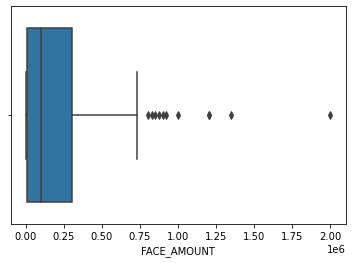

In [28]:
sns.boxplot(x= X_train['FACE_AMOUNT'])

In [29]:
sns.set(rc={'figure.figsize':(7,7)})
sns.set(font_scale=1.5)


[Text(0.5, 0, 'index')]

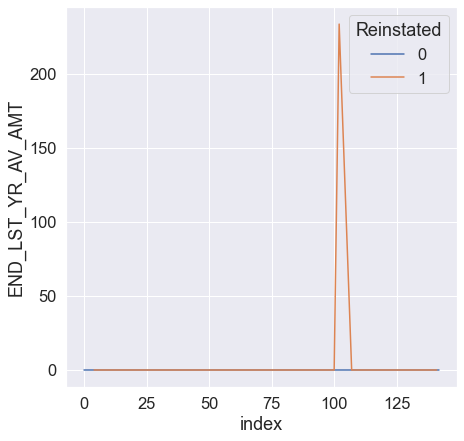

In [30]:
fig = sns.lineplot(x=X_tint.index,y=X_train.END_LST_YR_AV_AMT,markevery=1,markers='d',data=X_tint,hue=y_train)
fig.set(xlabel='index')

[Text(0.5, 0, 'index')]

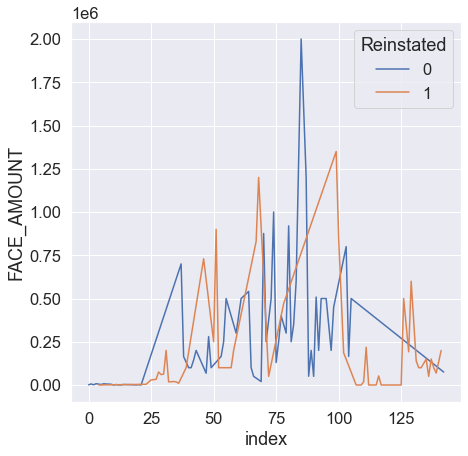

In [31]:
fig = sns.lineplot(x=X_tint.index,y=X_train.FACE_AMOUNT,markevery=1,markers='d',data=X_tint,hue=y_train)
fig.set(xlabel='index')

<AxesSubplot:xlabel='Reinstated', ylabel='ADDN_D_D_NEXT_YEAR'>

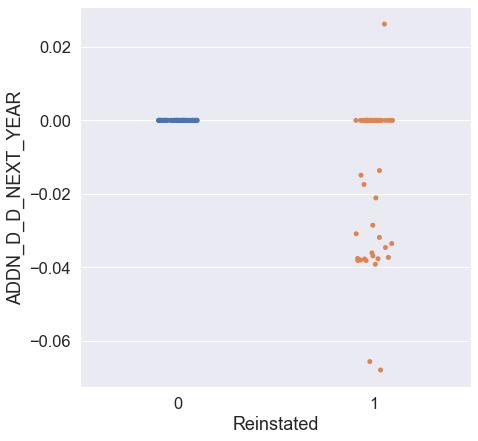

In [32]:
 sns.stripplot(x=y_train,y=X_train.ADDN_D_D_NEXT_YEAR)

C:\Users\Mirnalini\Anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 30.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<AxesSubplot:xlabel='ADDN_D_D_PAST_YEAR'>

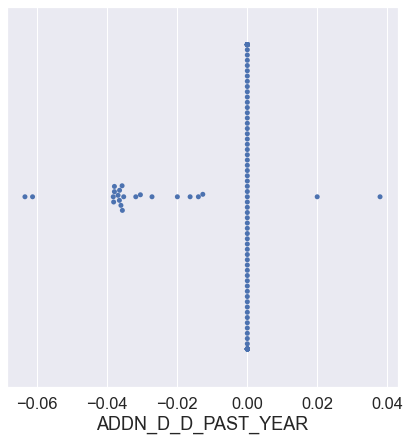

In [33]:
 sns.swarmplot(x=X_tint['ADDN_D_D_PAST_YEAR'])

C:\Users\Mirnalini\Anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 53.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<AxesSubplot:xlabel='Reinstated', ylabel='ADDN_D_D_PAST_YEAR'>

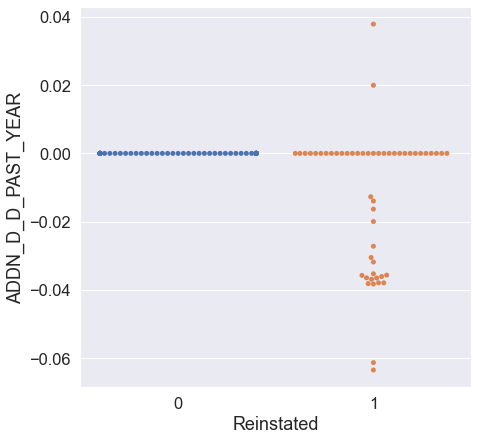

In [34]:
 sns.swarmplot(y=X_tint['ADDN_D_D_PAST_YEAR'],x=y_train)

(array([ 2.,  0.,  0., 14.,  2.,  3., 92.,  0.,  0.,  1.]),
 array([-0.07036 , -0.060272, -0.050184, -0.040096, -0.030008, -0.01992 ,
        -0.009832,  0.000256,  0.010344,  0.020432,  0.03052 ]),
 <BarContainer object of 10 artists>)

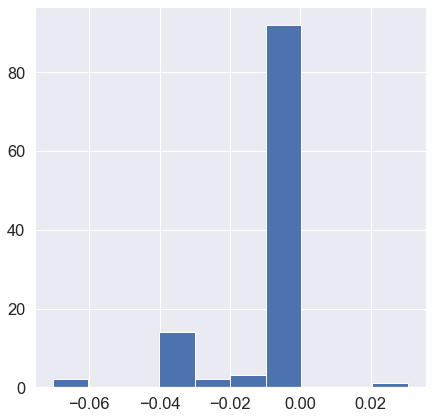

In [35]:
import matplotlib.pyplot as plt
plt.hist(X_tint['ADDN_D_YEAR_AFTR'])

<AxesSubplot:ylabel='ILL_DIV_SCAL_YEAR'>

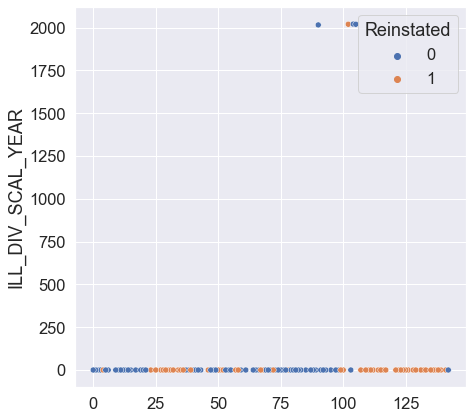

In [36]:
sns.scatterplot(x=X_tint.index,y=X_tint['ILL_DIV_SCAL_YEAR'],hue=y_train)


C:\Users\Mirnalini\Anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='ILL_DIV_SCAL_YEAR'>

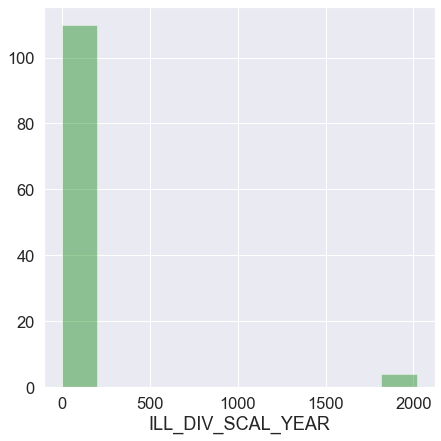

In [37]:
sns.distplot(X_tint['ILL_DIV_SCAL_YEAR'],kde=False,color='green',bins=10)

C:\Users\Mirnalini\Anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 48.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Mirnalini\Anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 42.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<AxesSubplot:xlabel='Reinstated', ylabel='ILL_DIV_SCAL_YEAR'>

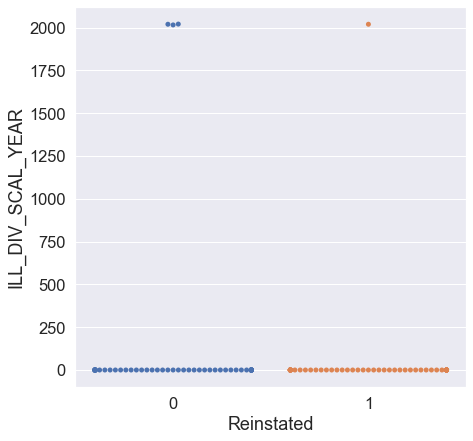

In [38]:
 sns.swarmplot(y=X_tint['ILL_DIV_SCAL_YEAR'],x=y_train)

<AxesSubplot:xlabel='POLICY_INDEX', ylabel='Density'>

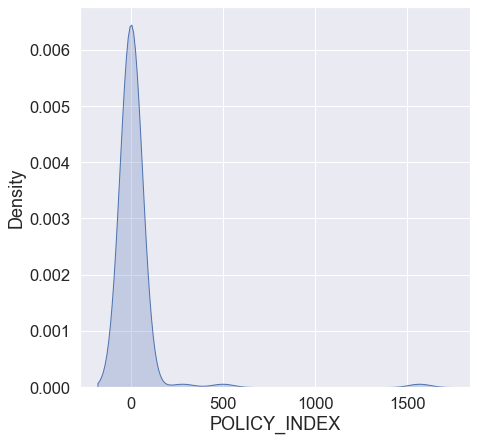

In [39]:
sns.kdeplot(X_tint['POLICY_INDEX'],shade=True)

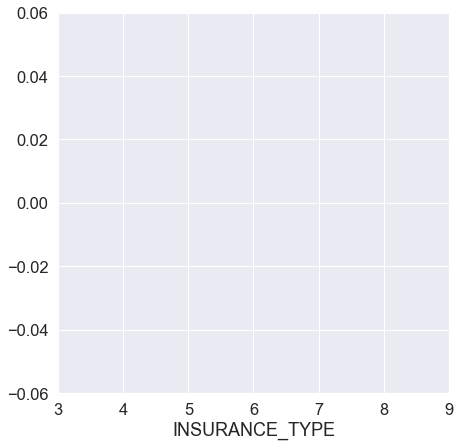

In [40]:
fig,ax = plt.subplots()
sns.rugplot(X_tint['INSURANCE_TYPE'])
ax.set_xlim(3,9)
plt.show()

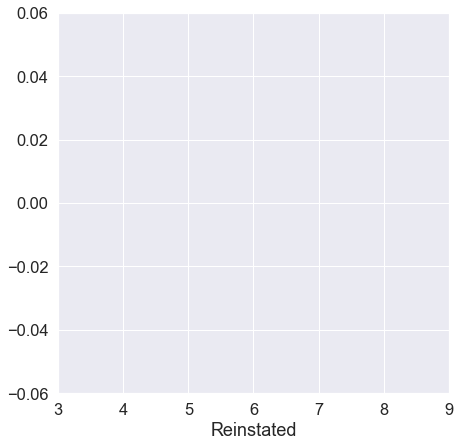

In [41]:
fig,ax = plt.subplots()
sns.rugplot(y_train)
ax.set_xlim(3,9)
plt.show()

<AxesSubplot:xlabel='variable', ylabel='value'>

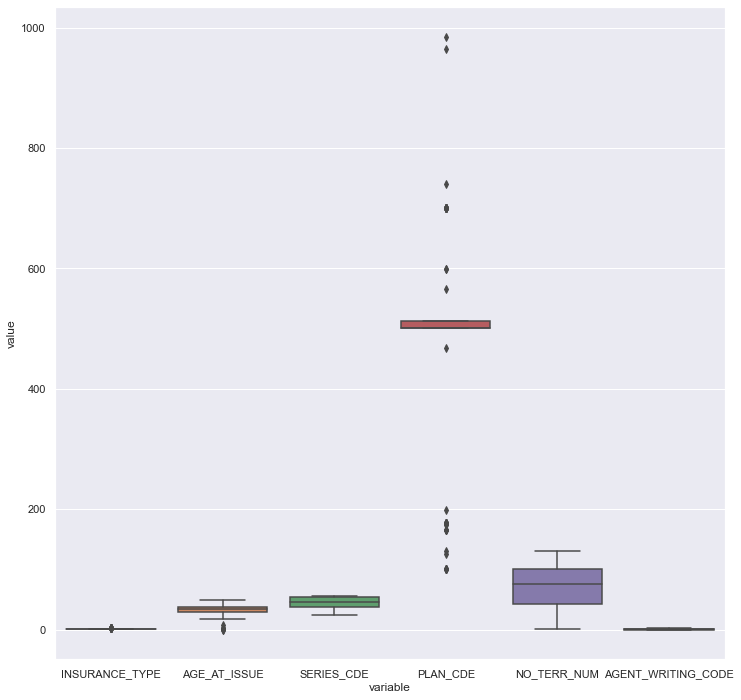

In [42]:
sns.set(rc={'figure.figsize':(12,12)})
sns.boxplot(x="variable",y="value",data=pd.melt(X_tint.iloc[:,0:6]))

<AxesSubplot:xlabel='variable', ylabel='value'>

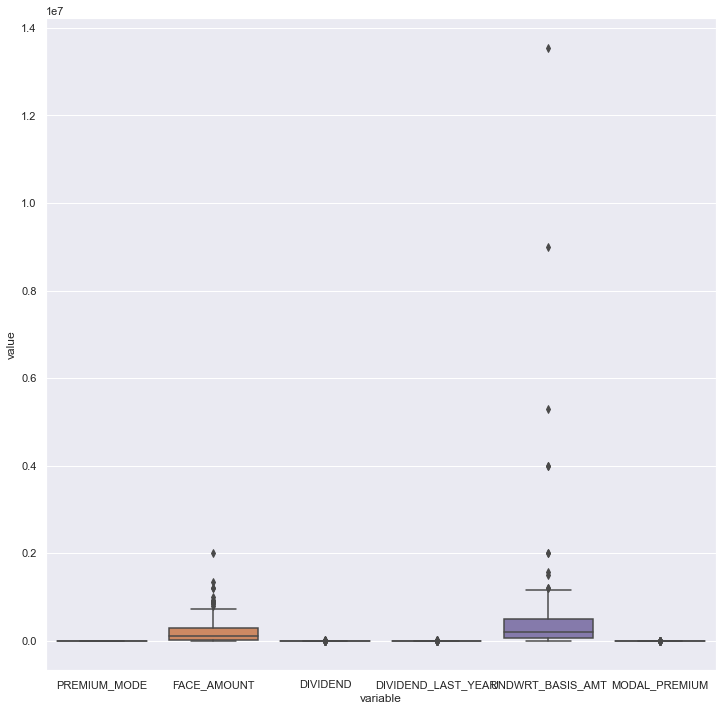

In [43]:
sns.set(rc={'figure.figsize':(12,12)})
sns.boxplot(x="variable",y="value",data=pd.melt(X_tint.iloc[:,6:12]))

<AxesSubplot:xlabel='variable', ylabel='value'>

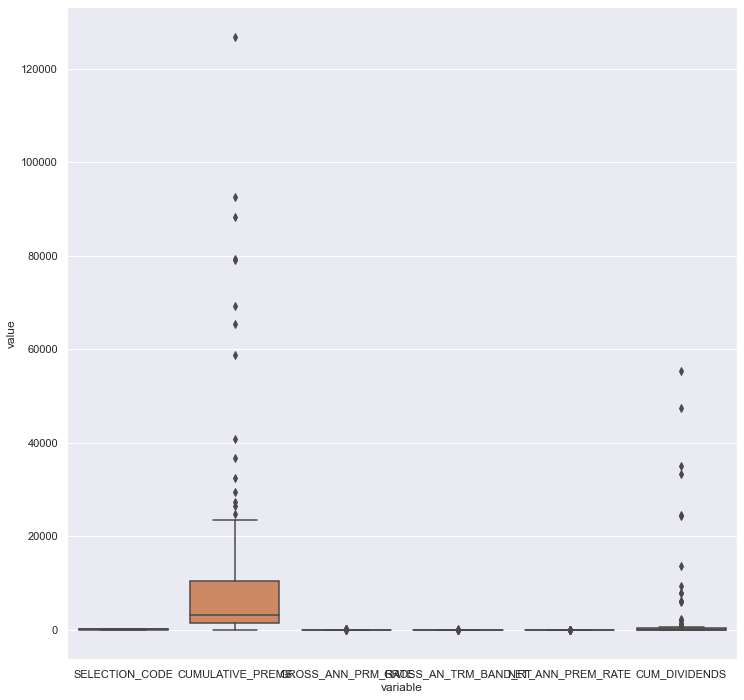

In [44]:
 sns.set(rc={'figure.figsize':(12,12)})
sns.boxplot(x="variable",y="value",data=pd.melt(X_tint.iloc[:,12:18]))

<AxesSubplot:xlabel='variable', ylabel='value'>

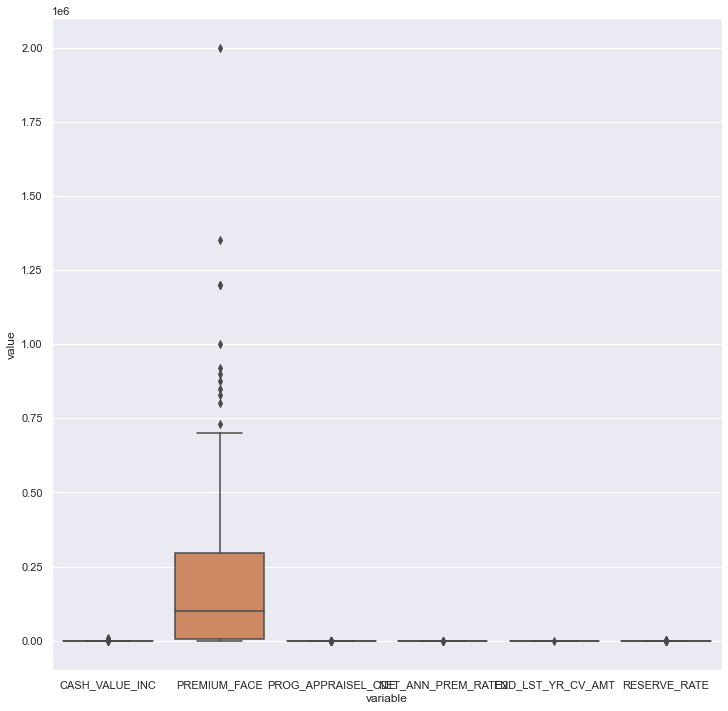

In [45]:
sns.set(rc={'figure.figsize':(12,12)})
sns.boxplot(x="variable",y="value",data=pd.melt(X_tint.iloc[:,18:24]))

<AxesSubplot:xlabel='variable', ylabel='value'>

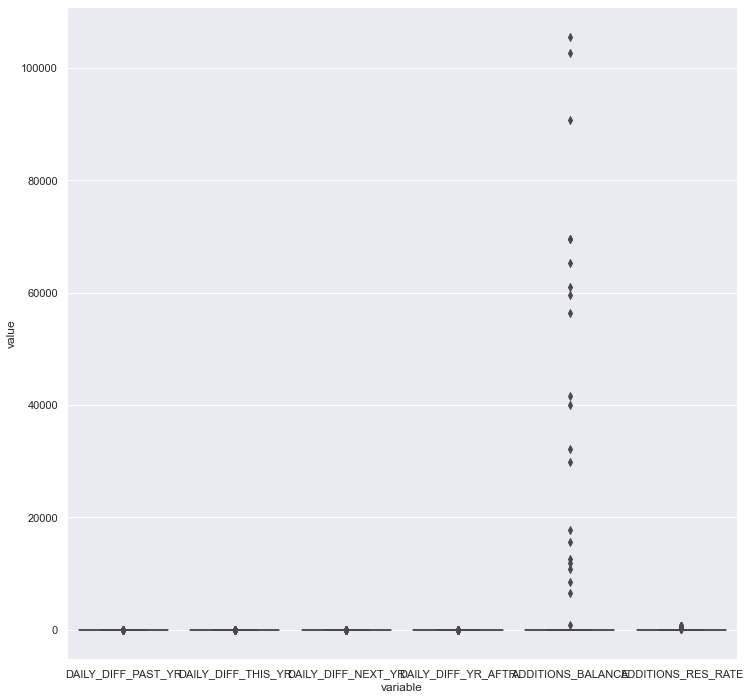

In [46]:
sns.set(rc={'figure.figsize':(12,12)})
sns.boxplot(x="variable",y="value",data=pd.melt(X_tint.iloc[:,24:30]))

<AxesSubplot:xlabel='variable', ylabel='value'>

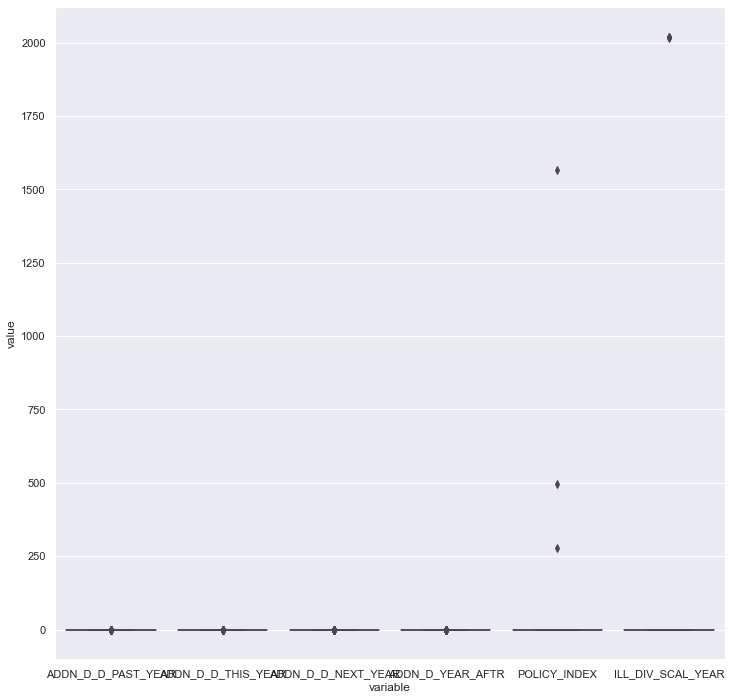

In [47]:
sns.set(rc={'figure.figsize':(12,12)})
sns.boxplot(x="variable",y="value",data=pd.melt(X_tint.iloc[:,30:36]))

<AxesSubplot:xlabel='variable', ylabel='value'>

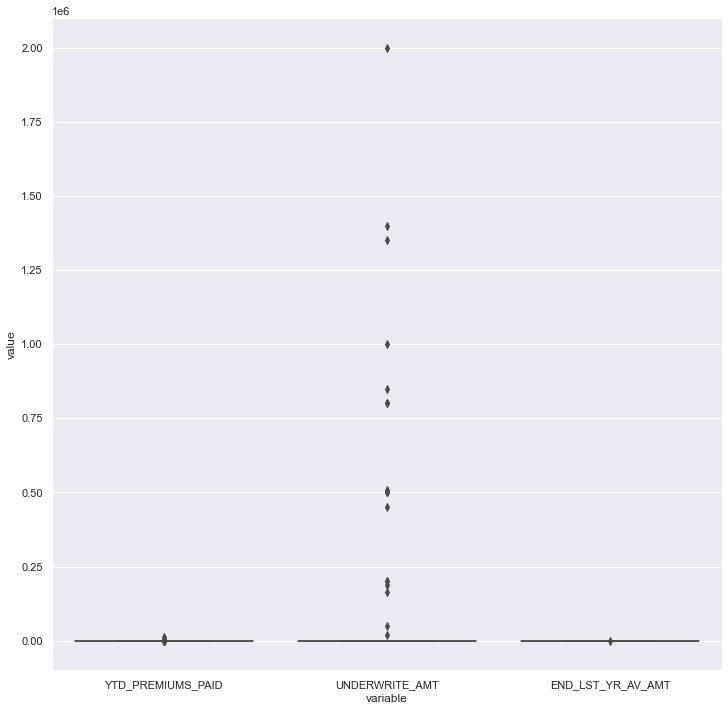

In [48]:
sns.set(rc={'figure.figsize':(12,12)})
sns.boxplot(x="variable",y="value",data=pd.melt(X_tint.iloc[:,36:40]))

{'bodies': [<matplotlib.collections.PolyCollection at 0x1cf4f0965c0>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x1cf4f0965f8>,
 'cmins': <matplotlib.collections.LineCollection at 0x1cf4f096ac8>,
 'cbars': <matplotlib.collections.LineCollection at 0x1cf4f096cf8>,
 'cmedians': <matplotlib.collections.LineCollection at 0x1cf4f096f60>}

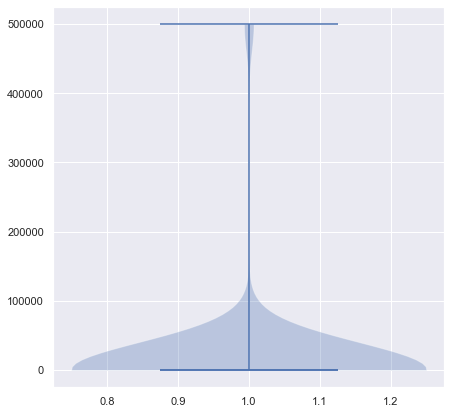

In [49]:
plt.figure(figsize=(7,7))
plt.violinplot(X_tint.iloc[0].values,showmedians=True)

<AxesSubplot:xlabel='Reinstated', ylabel='ADDN_D_D_NEXT_YEAR'>

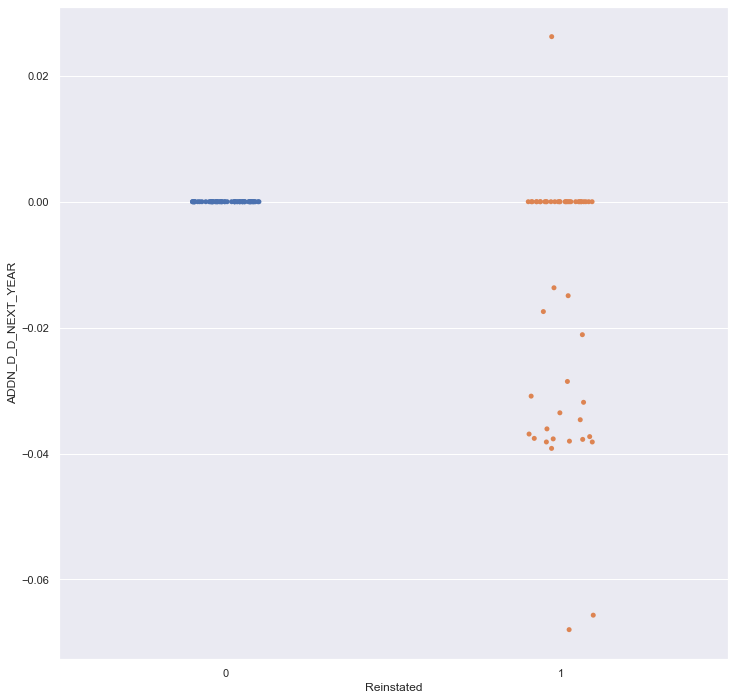

In [50]:
 sns.stripplot(x=y_train,y=X_train.ADDN_D_D_NEXT_YEAR)

<AxesSubplot:xlabel='Reinstated', ylabel='ADDN_D_D_PAST_YEAR'>

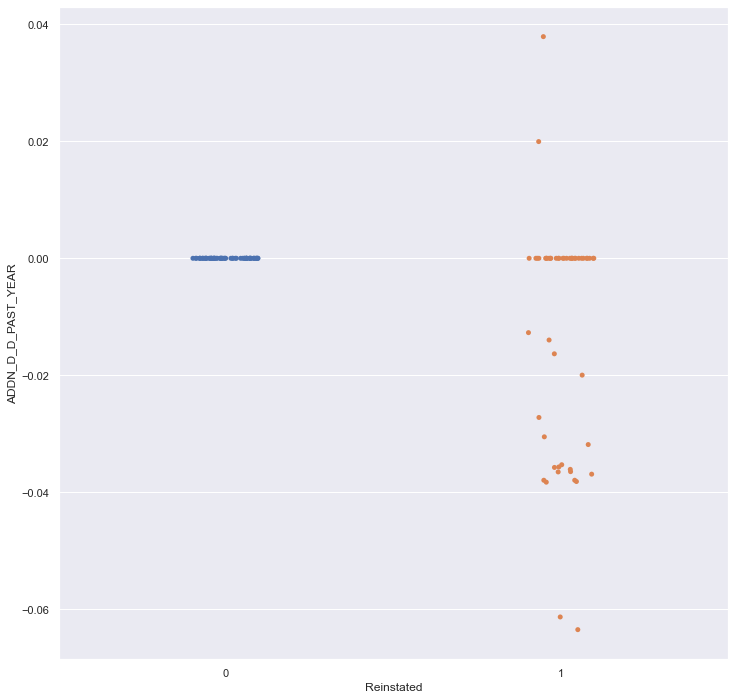

In [51]:
 sns.stripplot(x=y_train,y=X_train.ADDN_D_D_PAST_YEAR)

<AxesSubplot:xlabel='Reinstated', ylabel='ADDN_D_D_THIS_YEAR'>

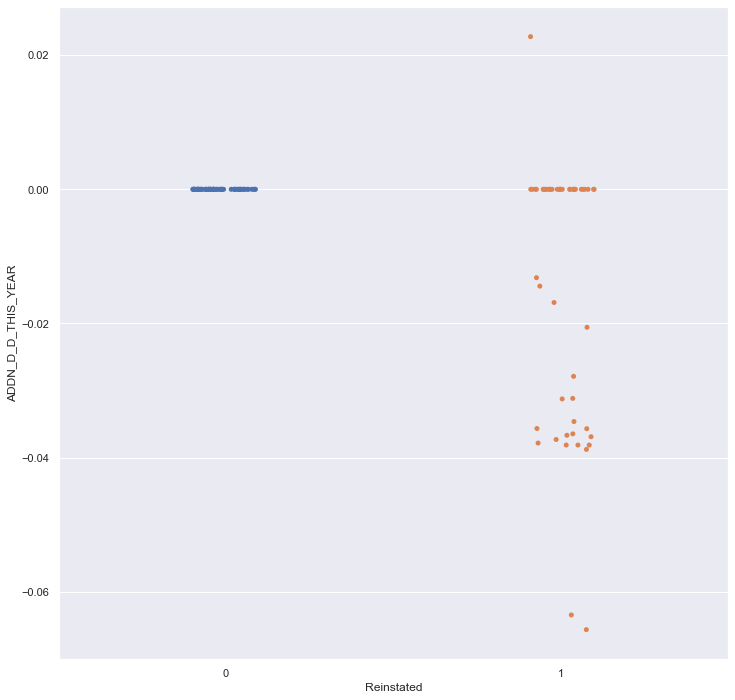

In [52]:
 sns.stripplot(x=y_train,y=X_train.ADDN_D_D_THIS_YEAR)

<AxesSubplot:xlabel='Reinstated', ylabel='ADDN_D_YEAR_AFTR'>

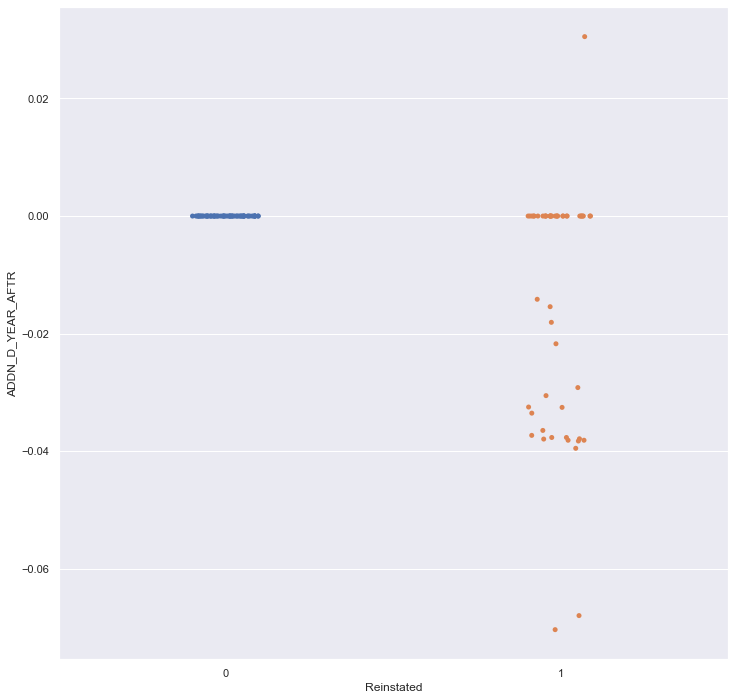

In [53]:
 sns.stripplot(x=y_train,y=X_train.ADDN_D_YEAR_AFTR)

C:\Users\Mirnalini\Anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='END_LST_YR_AV_AMT', ylabel='Density'>

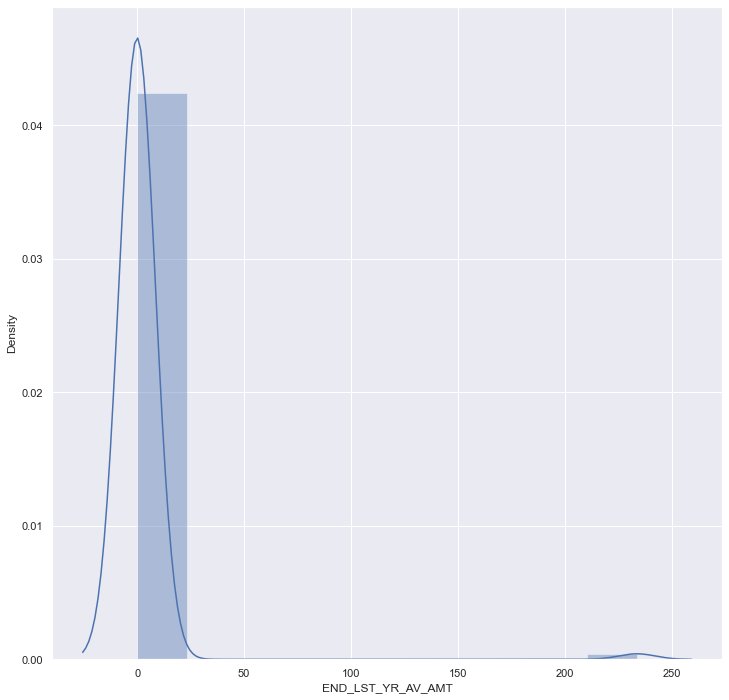

In [54]:
sns.distplot(X_tint['END_LST_YR_AV_AMT'])

In [55]:
catcor = X_tcatstr.corr()

In [56]:
incor = X_tint.corr()

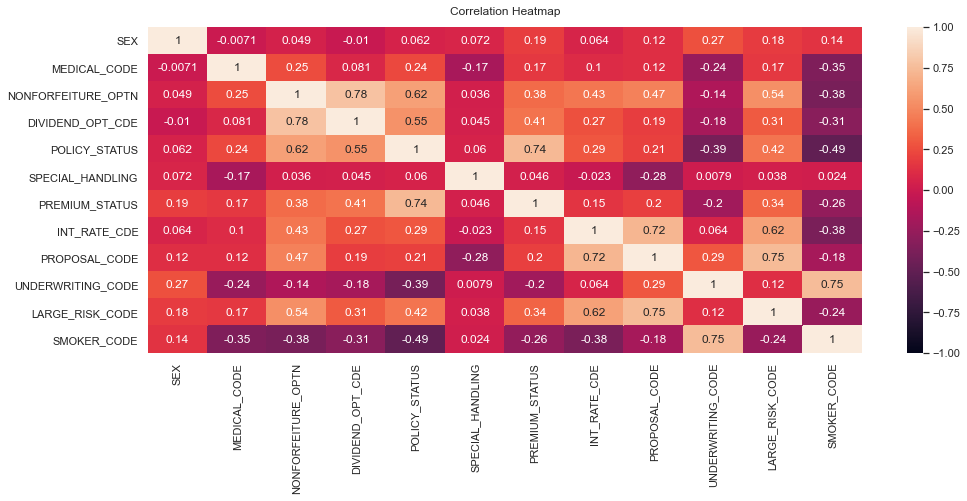

In [57]:
# Increase the size of the heatmap.
plt.figure(figsize=(16, 6))
# Store heatmap object in a variable to easily access it when you want to include more features (such as title).
# Set the range of values to be displayed on the colormap from -1 to 1, and set the annotation to True to display the correlation values on the heatmap.
heatmap = sns.heatmap(catcor, vmin=-1, vmax=1, annot=True)
# Give a title to the heatmap. Pad defines the distance of the title from the top of the heatmap.
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12);


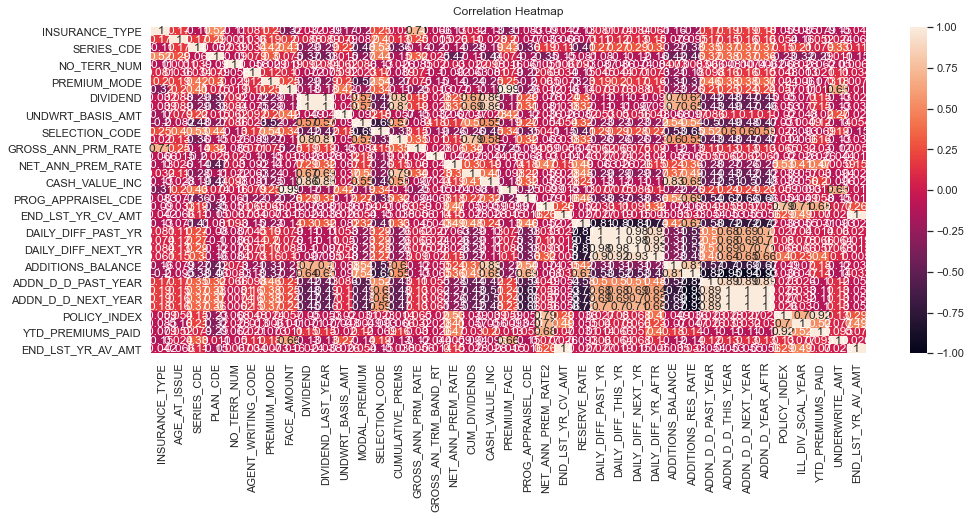

In [58]:
# Increase the size of the heatmap.
plt.figure(figsize=(16, 6))
# Store heatmap object in a variable to easily access it when you want to include more features (such as title).
# Set the range of values to be displayed on the colormap from -1 to 1, and set the annotation to True to display the correlation values on the heatmap.
heatmap = sns.heatmap(incor, vmin=-1, vmax=1, annot=True)
# Give a title to the heatmap. Pad defines the distance of the title from the top of the heatmap.
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12);


In [59]:
X_tint.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 114 entries, 126 to 47
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   INSURANCE_TYPE        114 non-null    int64  
 1   AGE_AT_ISSUE          114 non-null    int64  
 2   SERIES_CDE            114 non-null    int64  
 3   PLAN_CDE              114 non-null    int64  
 4   NO_TERR_NUM           114 non-null    int64  
 5   AGENT_WRITING_CODE    114 non-null    int64  
 6   PREMIUM_MODE          114 non-null    int64  
 7   FACE_AMOUNT           114 non-null    int64  
 8   DIVIDEND              114 non-null    int64  
 9   DIVIDEND_LAST_YEAR    114 non-null    int64  
 10  UNDWRT_BASIS_AMT      114 non-null    int64  
 11  MODAL_PREMIUM         114 non-null    int64  
 12  SELECTION_CODE        114 non-null    int64  
 13  CUMULATIVE_PREMS      114 non-null    int64  
 14  GROSS_ANN_PRM_RATE    114 non-null    int64  
 15  GROSS_AN_TRM_BAND_RT  

In [60]:
X_tcatstr.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 114 entries, 126 to 47
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   SEX                 114 non-null    int32
 1   MEDICAL_CODE        114 non-null    int32
 2   NONFORFEITURE_OPTN  114 non-null    int32
 3   DIVIDEND_OPT_CDE    114 non-null    int32
 4   POLICY_STATUS       114 non-null    int32
 5   SPECIAL_HANDLING    114 non-null    int32
 6   PREMIUM_STATUS      114 non-null    int32
 7   INT_RATE_CDE        114 non-null    int32
 8   PROPOSAL_CODE       114 non-null    int32
 9   UNDERWRITING_CODE   114 non-null    int64
 10  LARGE_RISK_CODE     114 non-null    int64
 11  SMOKER_CODE         114 non-null    int64
dtypes: int32(9), int64(3)
memory usage: 12.6 KB


# Extracting date features in a separate dataframe

In [61]:

X_tdate = X_train.select_dtypes(include='datetime64[ns]')
X_vdate = X_valid.select_dtypes(include='datetime64[ns]')

In [62]:
X_tdate

,POL_ANNIV_DTE,PREM_PAID_TO_DTE,DIVIDEND_Y_DTE,POL_SELECTION_DTE,MATURITY_YEAR
126,1970-01-01 00:00:00.019840709,1970-01-01 00:00:00.020080109,1970-01-01 00:00:00.000002007,1970-01-01 00:00:00.020091009,1970-01-01 00:00:00.000002023
2,1970-01-01 00:00:00.020031021,1970-01-01 00:00:00.020100821,1970-01-01 00:00:00.000002009,1970-01-01 00:00:00.020120821,1970-01-01 00:00:00.000002039
27,1970-01-01 00:00:00.019860826,1970-01-01 00:00:00.020140626,1970-01-01 00:00:00.000002016,1970-01-01 00:00:00.020220203,1970-01-01 00:00:00.000002017
125,1970-01-01 00:00:00.019811228,1970-01-01 00:00:00.020141228,1970-01-01 00:00:00.000002013,1970-01-01 00:00:00.020141208,1970-01-01 00:00:00.000002039
10,1970-01-01 00:00:00.020080521,1970-01-01 00:00:00.020100821,1970-01-01 00:00:00.000002010,1970-01-01 00:00:00.020120821,1970-01-01 00:00:00.000002039
...,...,...,...,...,...
9,1970-01-01 00:00:00.020060706,1970-01-01 00:00:00.020080606,1970-01-01 00:00:00.000002007,1970-01-01 00:00:00.020100606,1970-01-01 00:00:00.000002033
103,1970-01-01 00:00:00.020191210,1970-01-01 00:00:00.020200210,1970-01-01 00:00:00.000002019,1970-01-01 00:00:00.020250210,1970-01-01 00:00:00.000002068
67,1970-01-01 00:00:00.020031105,1970-01-01 00:00:00.020080305,1970-01-01 00:00:00.000002007,1970-01-01 00:00:00.020100305,1970-01-01 00:00:00.000002023
117,1970-01-01 00:00:00.019801020,1970-01-01 00:00:00.020110420,1970-01-01 00:00:00.000002010,1970-01-01 00:00:00.020110930,1970-01-01 00:00:00.000002043


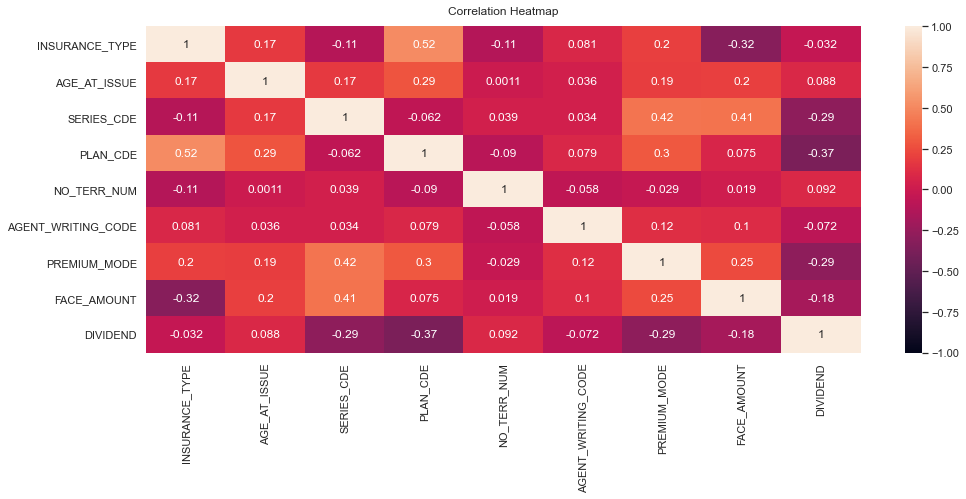

In [95]:

incorr1= X_tint.columns[0:9]
aa = X_tint[incorr1].corr()
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(aa, vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12);

    

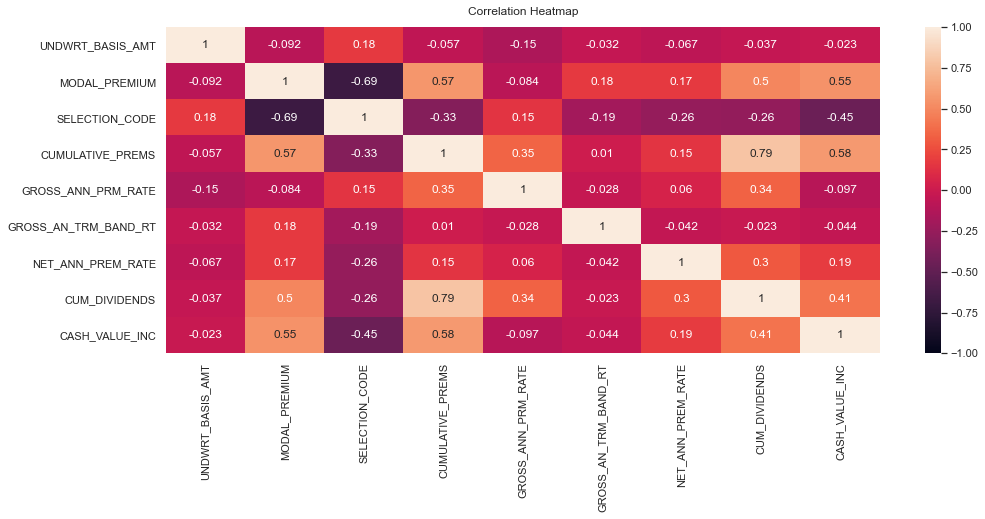

In [96]:
incorr1= X_tint.columns[10:19]
aa = X_tint[incorr1].corr()
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(aa, vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12);

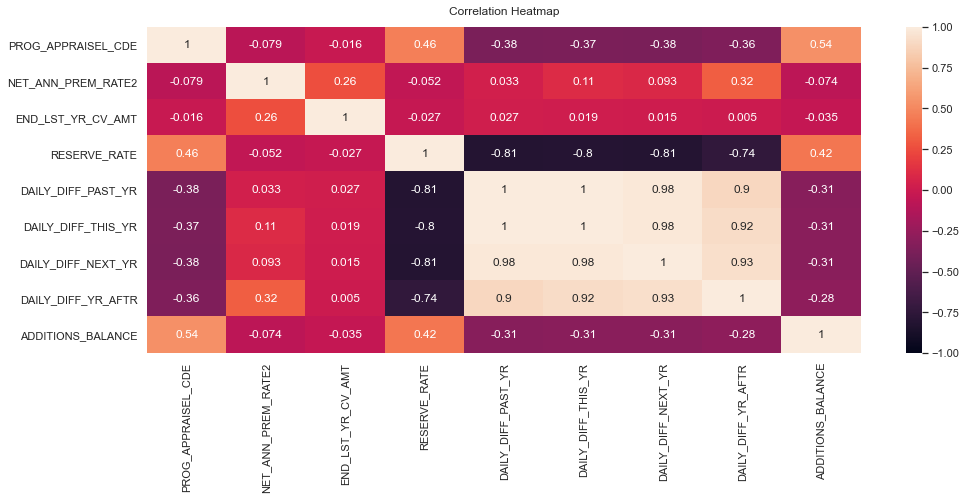

In [97]:
incorr1= X_tint.columns[20:29]
aa = X_tint[incorr1].corr()
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(aa, vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12);

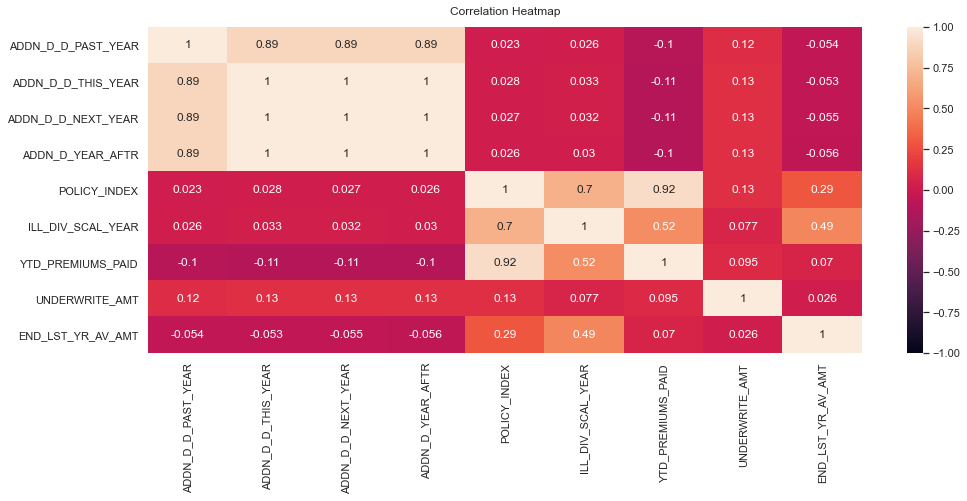

In [98]:
incorr1= X_tint.columns[30:39]
aa = X_tint[incorr1].corr()
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(aa, vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12);

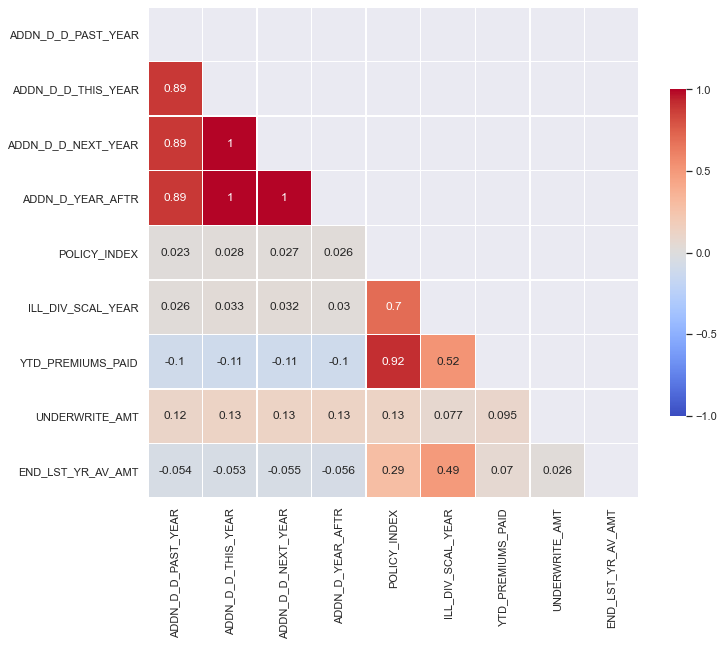

In [108]:
import numpy as np
f, ax = plt.subplots(figsize=(11, 15))

mask = np.zeros_like(aa, dtype=np.bool)
mask[np.triu_indices_from(mask)]= True


heatmap = sns.heatmap(aa,
                      mask = mask,
                      square = True,
                      linewidths = .5,
                      cmap = 'coolwarm',
                      cbar_kws = {'shrink': .4,
                                'ticks' : [-1, -.5, 0, 0.5, 1]},
                      vmin = -1,
                      vmax = 1,
                      annot = True,
                      annot_kws = {'size': 12})

#add the column names as labels
ax.set_yticklabels(aa.columns, rotation = 0)
ax.set_xticklabels(aa.columns)

sns.set_style({'xtick.bottom': True}, {'ytick.left': True})